In [18]:
from pathlib import Path
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCUMENT_DIR = Path('documents')
OUTPUT_DIR = Path('outputs')
DOCUMENT_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print('Folders are ready.')

Folders are ready.


In [19]:
sources = {
    'document1_unesco_digital_education': 'https://www.unesco.org/en/digital-education',
    'document2_oecd_ai': 'https://www.oecd.org/en/topics/artificial-intelligence.html',
    'document3_unesco_ai': 'https://www.unesco.org/en/artificial-intelligence',
    'document4_oecd_education': 'https://www.oecd.org/en/topics/education.html',
    'document5_unesco_education': 'https://www.unesco.org/en/education',
    'document6_oecd_education_skills': 'https://www.oecd.org/en/topics/education-and-skills.html'
}

headers = {'User-Agent': 'Mozilla/5.0'}
download_log = []

for name, url in sources.items():
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, 'html.parser')
        for element in soup(['script', 'style', 'nav', 'footer', 'header']):
            element.decompose()

        text = soup.get_text(separator=' ', strip=True)
        file_path = DOCUMENT_DIR / f'{name}.txt'
        file_path.write_text(text, encoding='utf-8')

        download_log.append({'document': name, 'url': url, 'characters_saved': len(text), 'status': 'Success'})
        print(f'Saved: {file_path} | characters: {len(text)}')

    except Exception as error:
        download_log.append({'document': name, 'url': url, 'characters_saved': 0, 'status': f'Failed: {error}'})
        print(f'Could not download {url}\nReason: {error}')

download_log_df = pd.DataFrame(download_log)
download_log_df

Saved: documents\document1_unesco_digital_education.txt | characters: 311
Could not download https://www.oecd.org/en/topics/artificial-intelligence.html
Reason: 403 Client Error: Forbidden for url: https://www.oecd.org/en/topics/artificial-intelligence.html
Saved: documents\document3_unesco_ai.txt | characters: 311
Could not download https://www.oecd.org/en/topics/education.html
Reason: 403 Client Error: Forbidden for url: https://www.oecd.org/en/topics/education.html
Saved: documents\document5_unesco_education.txt | characters: 311
Could not download https://www.oecd.org/en/topics/education-and-skills.html
Reason: 403 Client Error: Forbidden for url: https://www.oecd.org/en/topics/education-and-skills.html


,document,url,characters_saved,status
0,document1_unesco_digital_education,https://www.unesco.org/en/digital-education,311,Success
1,document2_oecd_ai,https://www.oecd.org/en/topics/artificial-inte...,0,Failed: 403 Client Error: Forbidden for url: h...
2,document3_unesco_ai,https://www.unesco.org/en/artificial-intelligence,311,Success
3,document4_oecd_education,https://www.oecd.org/en/topics/education.html,0,Failed: 403 Client Error: Forbidden for url: h...
4,document5_unesco_education,https://www.unesco.org/en/education,311,Success
5,document6_oecd_education_skills,https://www.oecd.org/en/topics/education-and-s...,0,Failed: 403 Client Error: Forbidden for url: h...


In [20]:
files = sorted(DOCUMENT_DIR.glob('*.txt'))

file_table = pd.DataFrame({
    'file_name': [file.name for file in files],
    'characters': [len(file.read_text(encoding='utf-8')) for file in files]
})

display(file_table)
print('Number of documents:', len(files))

if len(files) < 5:
    raise ValueError('At least 5 usable text documents are required.')

,file_name,characters
0,Artificial_Intelligence.txt,0
1,Basketball.txt,60409
2,Climate_Change.txt,0
3,Computer_Science.txt,0
4,Deep_Learning.txt,0
5,document1.txt,311
6,document1_unesco_digital_education.txt,311
7,document3.txt,311
8,document3_unesco_ai.txt,311
9,document5.txt,311


Number of documents: 14


In [21]:
document_names = [file.stem for file in files]
documents = [file.read_text(encoding='utf-8') for file in files]

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b'
)

tfidf_matrix = vectorizer.fit_transform(documents)

print('Number of documents:', len(documents))
print('Vocabulary size:', len(vectorizer.vocabulary_))
print('TF-IDF matrix shape:', tfidf_matrix.shape)

Number of documents: 14
Vocabulary size: 3278
TF-IDF matrix shape: (14, 3278)


In [22]:
similarity_matrix = cosine_similarity(tfidf_matrix)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=document_names,
    columns=document_names
)

display(similarity_df.round(4))
similarity_df.to_csv(OUTPUT_DIR / 'similarity_matrix.csv')
print('Saved:', OUTPUT_DIR / 'similarity_matrix.csv')

,Artificial_Intelligence,Basketball,Climate_Change,Computer_Science,Deep_Learning,document1,document1_unesco_digital_education,document3,document3_unesco_ai,document5,document5_unesco_education,Football,Machine_Learning,Renewable_Energy
Artificial_Intelligence,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
Basketball,0.0,1.0000,0.0,0.0,0.0,0.0017,0.0017,0.0017,0.0017,0.0017,0.0017,0.3404,0.0,0.0
Climate_Change,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
Computer_Science,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
Deep_Learning,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0
document1,0.0,0.0017,0.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0061,0.0,0.0
document1_unesco_digital_education,0.0,0.0017,0.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0061,0.0,0.0
document3,0.0,0.0017,0.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0061,0.0,0.0
document3_unesco_ai,0.0,0.0017,0.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0061,0.0,0.0
document5,0.0,0.0017,0.0,0.0,0.0,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0061,0.0,0.0


Saved: outputs\similarity_matrix.csv


In [23]:
pairs = []

for i in range(len(document_names)):
    for j in range(i + 1, len(document_names)):
        pairs.append({
            'Document 1': document_names[i],
            'Document 2': document_names[j],
            'Similarity Score': similarity_matrix[i, j]
        })

ranked_pairs_df = (
    pd.DataFrame(pairs)
    .sort_values('Similarity Score', ascending=False)
    .reset_index(drop=True)
)

display(ranked_pairs_df.round(4))
ranked_pairs_df.to_csv(OUTPUT_DIR / 'ranked_document_pairs.csv', index=False)
print('Saved:', OUTPUT_DIR / 'ranked_document_pairs.csv')

,Document 1,Document 2,Similarity Score
0,document3,document5_unesco_education,1.0
1,document3,document5,1.0
2,document3,document3_unesco_ai,1.0
3,document3_unesco_ai,document5_unesco_education,1.0
4,document5,document5_unesco_education,1.0
...,...,...,...
86,document5_unesco_education,Machine_Learning,0.0
87,document5_unesco_education,Renewable_Energy,0.0
88,Football,Machine_Learning,0.0
89,Football,Renewable_Energy,0.0


Saved: outputs\ranked_document_pairs.csv


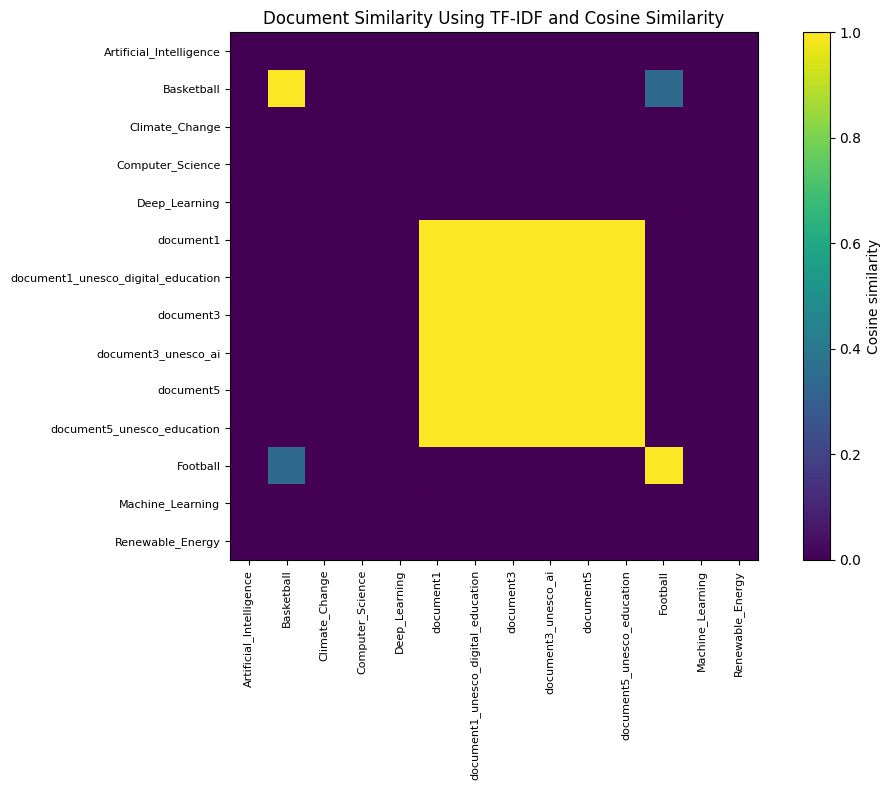

In [24]:
plt.figure(figsize=(11, 8))
plt.imshow(similarity_matrix, interpolation='nearest')
plt.colorbar(label='Cosine similarity')
plt.xticks(range(len(document_names)), document_names, rotation=90, fontsize=8)
plt.yticks(range(len(document_names)), document_names, fontsize=8)
plt.title('Document Similarity Using TF-IDF and Cosine Similarity')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'similarity_heatmap.png', dpi=300)
plt.show()

,Document 1,Document 2,Similarity Score
0,document3,document5_unesco_education,1.0
1,document3,document5,1.0
2,document3,document3_unesco_ai,1.0
3,document3_unesco_ai,document5_unesco_education,1.0
4,document5,document5_unesco_education,1.0


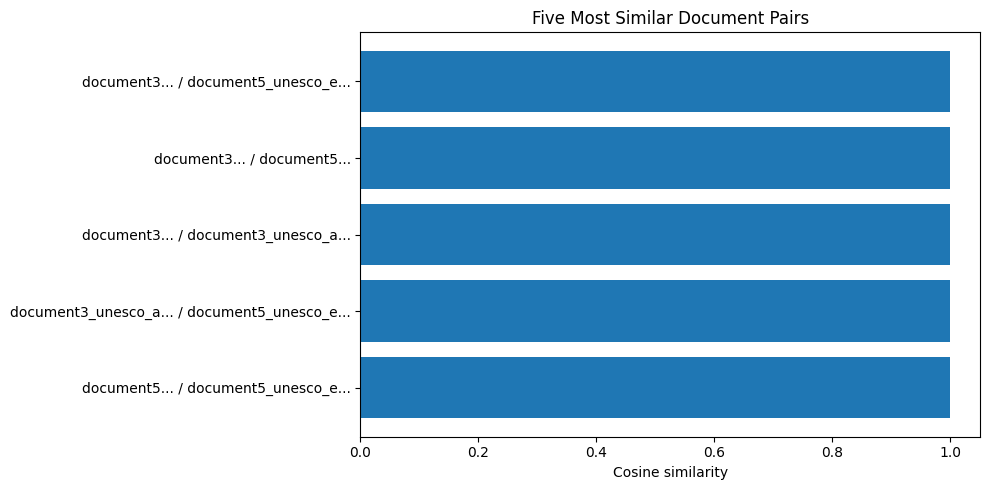

In [25]:
top5 = ranked_pairs_df.head(5).copy()
display(top5.round(4))

plt.figure(figsize=(10, 5))
labels = [
    f'{row["Document 1"][:18]}... / {row["Document 2"][:18]}...'
    for _, row in top5.iterrows()
]
plt.barh(labels[::-1], top5['Similarity Score'].values[::-1])
plt.xlabel('Cosine similarity')
plt.title('Five Most Similar Document Pairs')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top5_similarity_pairs.png', dpi=300)
plt.show()